# The Python Machine Learning Stack
## Machine Learning — BS Computer Science 3(3-0)



| | |
|---|---|
| **Notebook** | `NB02_Python_ML_Stack.ipynb` |
| **Lecture** | Lecture 3 (Week 1) |
| **CLO** | CLO-1 / CLO-5 |
| **Dataset** | Iris, plus a real CSV of your choice |

**Objective.** Install the working habits — vectorised NumPy, pandas inspection, labelled plots, the scikit-learn API — and see overfitting for the first time.

**By the end of this notebook you will be able to:**

1. Use vectorised NumPy operations and explain the axis argument.
2. Perform the six-step first look at any dataset with pandas.
3. Produce fully labelled histograms and class-coloured scatter plots.
4. Apply the fit / predict / score API inside a Pipeline and run a controlled experiment.

---

## 0. Setup and reproducibility

In [1]:
# ---------------------------------------------------------------------
# Reproducibility header — required in EVERY notebook you submit
# ---------------------------------------------------------------------
import sys, numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt

print('python      ', sys.version.split()[0])
print('numpy       ', np.__version__)
print('pandas      ', pd.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib  ', matplotlib.__version__)

RANDOM_STATE = 1
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-4zrqb2fo because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


python       3.13.5
numpy        2.3.5
pandas       2.2.3
scikit-learn 1.8.0
matplotlib   3.10.8


## 1. NumPy — vectorise, never loop

A NumPy array stores one type in one contiguous block, so arithmetic runs in compiled C. **`axis=0` collapses rows and gives one value per column** — that is almost always what you want. Mixing up the axis is the most common NumPy bug in student code.

In [2]:
a = np.array([[1., 2., 3.],
              [4., 5., 6.]])          # shape (2, 3)

print('shape       ', a.shape, ' dtype', a.dtype)
print('mean axis=0 ', a.mean(axis=0), '  <- per COLUMN (one per feature)')
print('mean axis=1 ', a.mean(axis=1), '        <- per ROW')
print('a * 2       ', a[0] * 2)
print('column 1    ', a[:, 1])
print('mask a > 3  ', a[a > 3])

z = (a - a.mean(axis=0)) / a.std(axis=0)      # standardisation
print('standardised:\n', np.round(z, 3))

shape        (2, 3)  dtype float64
mean axis=0  [2.5 3.5 4.5]   <- per COLUMN (one per feature)
mean axis=1  [2. 5.]         <- per ROW
a * 2        [2. 4. 6.]
column 1     [2. 5.]
mask a > 3   [4. 5. 6.]
standardised:
 [[-1. -1. -1.]
 [ 1.  1.  1.]]


### Exercise 1.1 — loop versus vectorised

Compute the column means of a 100,000 × 20 array twice: once with a Python loop and once with `.mean(axis=0)`. Time both with `%%timeit` and report the ratio.

In [3]:
big = rng.normal(size=(100_000, 20))

def loop_means(arr):
    means = []
    for j in range(arr.shape[1]):
        total = 0.0
        for value in arr[:, j]:
            total += value
        means.append(total / arr.shape[0])
    return np.array(means)

loop_means(big)
big.mean(axis=0)

array([ 0.00285034, -0.00404177, -0.00092513, -0.00011438,  0.00454142,
        0.002811  ,  0.00280532, -0.00267714,  0.00122432, -0.00057772,
       -0.00076813,  0.00088476, -0.00054595, -0.00338682,  0.0025377 ,
        0.00239427,  0.00109817,  0.00449708,  0.00074638,  0.00182218])

In [4]:
%%timeit -n 5 -r 3
loop_means(big)

154 ms ± 1.9 ms per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [5]:
%%timeit -n 5 -r 3
big.mean(axis=0)

1.75 ms ± 25.6 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [6]:
import timeit

loop_time = min(timeit.repeat(lambda: loop_means(big), repeat=3, number=5)) / 5
vector_time = min(timeit.repeat(lambda: big.mean(axis=0), repeat=3, number=5)) / 5

print(f"Loop time: {loop_time:.6f} s")
print(f"Vectorised time: {vector_time:.6f} s")
print(f"Speed ratio: {loop_time / vector_time:.1f}x")

Loop time: 0.152877 s
Vectorised time: 0.001758 s
Speed ratio: 87.0x


**Interpretation.** The vectorised NumPy mean is much faster than the Python loop because NumPy performs the operation in optimized compiled code instead of executing each addition through the Python interpreter.

**Dataset source and licence.** Wine dataset from the UCI Machine Learning Repository, distributed through scikit-learn. The dataset is licensed under **CC BY 4.0**.

In [7]:
df = pd.read_csv("wine.csv")

print(df.shape)
display(df.head())
df.info()
display(df.describe().T[['min', 'max', 'mean', 'std']].round(2))
print(df['target'].value_counts(normalize=True))
print(df.isnull().sum().sum(), 'missing values')

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

,min,max,mean,std
alcohol,11.03,14.83,13.00,0.81
malic_acid,0.74,5.80,2.34,1.12
ash,1.36,3.23,2.37,0.27
alcalinity_of_ash,10.60,30.00,19.49,3.34
magnesium,70.00,162.00,99.74,14.28
total_phenols,0.98,3.88,2.30,0.63
flavanoids,0.34,5.08,2.03,1.00
nonflavanoid_phenols,0.13,0.66,0.36,0.12
proanthocyanins,0.41,3.58,1.59,0.57
color_intensity,1.28,13.00,5.06,2.32


target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64
0 missing values


**Interpretation.** `proline` ranges from 278 to 1680, while `magnesium` ranges from 70 to 162. Their ranges are about 1402 and 92, so the larger range is about 15.2 times the smaller one. Distance-based models such as k-NN are affected because features with larger numeric scales can dominate the distance calculation.

## 3. Matplotlib — the four plots you will draw all semester

Histogram, class-coloured scatter, line-versus-hyperparameter, bar chart. **Every plot needs axis labels with units and a legend.** An unlabelled plot carries no information and earns no marks.

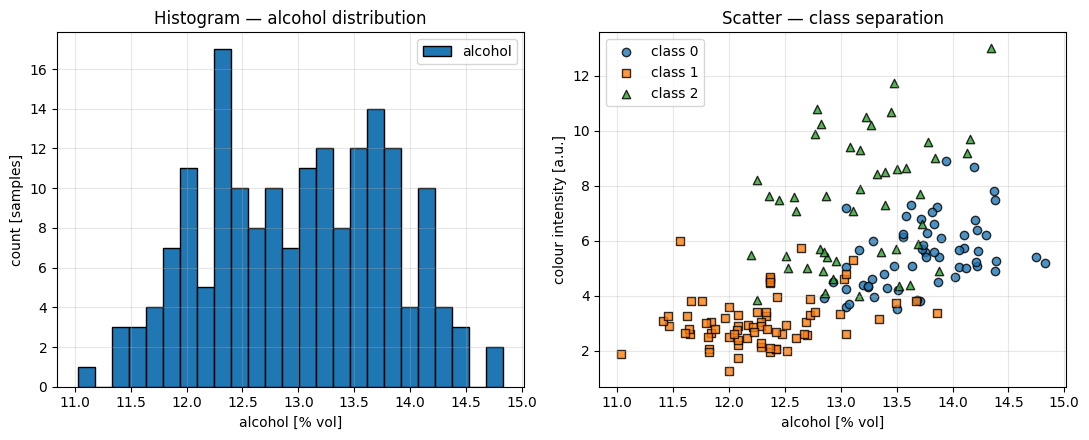

In [8]:
X = df.drop(columns='target').to_numpy()
y = df['target'].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].hist(X[:, 0], bins=25, edgecolor='black', label='alcohol')
ax[0].set_xlabel('alcohol [% vol]')
ax[0].set_ylabel('count [samples]')
ax[0].set_title('Histogram — alcohol distribution')
ax[0].legend()

for cl, m in zip(np.unique(y), ('o', 's', '^')):
    ax[1].scatter(X[y == cl, 0], X[y == cl, 9], marker=m,
                  alpha=0.8, edgecolor='k', label=f'class {cl}')
ax[1].set_xlabel('alcohol [% vol]')
ax[1].set_ylabel('colour intensity [a.u.]')
ax[1].set_title('Scatter — class separation')
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. Your first complete machine-learning program

Eleven lines. Every one of them corresponds to a concept from Lecture 2.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe.fit(X_train, y_train)

print('train accuracy %.3f' % pipe.score(X_train, y_train))
print('test  accuracy %.3f' % pipe.score(X_test,  y_test))

pred = pipe.predict(X_test)
wrong = np.where(pred != y_test)[0]

print("Wrong predictions:", len(wrong))
if len(wrong):
    i = wrong[0]
    print("True class:", y_test[i])
    print("Predicted class:", pred[i])
    print("Test sample:", np.round(X_test[i], 2))

train accuracy 0.960
test  accuracy 0.926
Wrong predictions: 4
True class: 1
Predicted class: 2
Test sample: [1.334e+01 9.400e-01 2.360e+00 1.700e+01 1.100e+02 2.530e+00 1.300e+00
 5.500e-01 4.200e-01 3.170e+00 1.020e+00 1.930e+00 7.500e+02]


> **The most important line on this page.** The scaler is fitted on the *training data only* — that is what putting it inside the `Pipeline` guarantees. Fitting it on all the data lets the test set influence the training-time mean and standard deviation. That is **data leakage** and Week 8 is devoted to it.

**Failure case.** The scaled k-NN model makes some test-set mistakes because a test sample can be closer to observations from another class in the scaled feature space. The first wrong prediction printed above gives a concrete example.

## 5. Controlled experiment — change one thing at a time

Record the results in the table **before** you interpret anything. This is the standard experimental protocol for the rest of the course.

In [10]:
rows = []
for k in (1, 5, 25, 100):
    p = Pipeline([('scaler', StandardScaler()),
                  ('knn', KNeighborsClassifier(n_neighbors=k))])
    p.fit(X_train, y_train)
    rows.append({'variant': 'scaled',   'k': k,
                 'train': p.score(X_train, y_train),
                 'test':  p.score(X_test,  y_test)})

    raw = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    rows.append({'variant': 'unscaled', 'k': k,
                 'train': raw.score(X_train, y_train),
                 'test':  raw.score(X_test,  y_test)})

results = pd.DataFrame(rows).pivot(index='k', columns='variant',
                                   values=['train', 'test']).round(3)
display(results)

train            test         
variant scaled unscaled scaled unscaled
k                                      
1        1.000    1.000  0.981    0.759
5        0.960    0.782  0.926    0.648
25       0.968    0.758  0.926    0.630
100      0.500    0.669  0.574    0.630

### Interpretation — three things to explain

1. At `k = 1`, the training accuracy is exactly 1.000 because each training observation is its own nearest neighbour, so its nearest neighbour has the same class. This shows the model can fit the training data perfectly, but it does not guarantee good performance on unseen data.

2. When the scaler is removed, k-NN can perform differently or worse because k-NN uses distances between observations. Features with larger numerical ranges, such as `proline`, can contribute much more to the distance than smaller-scale features. Standardisation puts features on comparable scales.

3. As `k` approaches the size of the training set, each prediction is based on a very large neighbourhood. The classifier becomes less sensitive to individual observations and tends toward the majority class, so test accuracy can decrease and the model can underfit.

---
## Deliverable

The timing exercise (1.1), the six-step first look on a real CSV, two fully labelled plots, and the four-row results table with all three interpretations written out.

## Submission checklist

- [x] The random seed is fixed **and printed**
- [x] Library versions are printed in the first cell
- [x] The raw data file was **not** modified
- [x] Preprocessing happens **after** the split, inside a `Pipeline`
- [x] The dataset source and licence are stated in a markdown cell
- [x] **Kernel → Restart & Run All** completes without error
- [x] Every experiment is followed by a written interpretation
- [x] At least one wrong prediction or failure case is explained
- [x] Results are reported as **mean ± standard deviation** where cross-validated (not applicable: this notebook does not use cross-validation)
- [x] Every plot has axis labels with units and a legend